## BHPT, PN, Newtonian kicks

In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")  # silence LAL warnings

# general modules
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
plt.rc('figure', figsize=(8, 5))
plt.rcParams.update({'text.usetex': True,'text.latex.preamble':r'\usepackage{amsmath}',
                     'font.family': 'serif','font.serif': ['Georgia'],'mathtext.fontset': 'cm',
                     'lines.linewidth': 1.8,'font.size': 18,'xtick.labelsize': 'large',
                     'ytick.labelsize': 'large','xtick.direction': 'in','ytick.direction': 'in',
                     'xtick.major.width': 1.4,'ytick.major.width': 1.4,'xtick.major.size': 5.,
                     'ytick.major.size': 5.,'ytick.right':True,'axes.labelsize': 'large',
                     'axes.titlesize': 'large','axes.grid': True,'grid.alpha': 0.5,
                     'lines.markersize': 12,'legend.borderpad': 0.2,'legend.fancybox': True,
                     'legend.fontsize': 15,'legend.framealpha': 0.7,'legend.handletextpad': 0.5,
                     'legend.labelspacing': 0.2,'legend.loc': 'best','savefig.bbox': 'tight',
                     'savefig.pad_inches': 0.05,'savefig.dpi': 80,'pdf.compression': 9})

import sys
sys.path.append("/Users/tousifislam/Research/projects/astro_projects/prec_hierarchical/gwGenealogy/")
import gwGenealogy

# import rit kick module
from gwGenealogy.remnants import bbh_final_state_precessing_NRSur7dq4Remnant
from gwGenealogy.remnants import bbh_final_kick_precessing_CLZM2007

Loaded NRSur7dq4Remnant fit.
Loaded NRSur3dq8Remnant fit.


In [2]:
# 1g : mass distribtuion
m1 = gwGenealogy.core.sample_powerlaw_1d(n_samples=1000, beta=-1.3, xmin=5, xmax=50, seed=40)
m2 = gwGenealogy.core.sample_powerlaw_1d(n_samples=1000, beta=-1.3, xmin=5, xmax=50, seed=50)
# 1g : spin distribution
s1_vec, s2_vec = gwGenealogy.core.sample_isotropic_spins(n_samples=1000, chi_min=0, chi_max=1)

In [3]:
from gwGenealogy.remnants import (bbh_final_kick_nonprecessing_Fitchett1983, 
                                  bbh_final_kick_nonprecessing_Kidder1995,
                                  bbh_final_kick_range_from_bhpt_FHH2004,
                                  bbh_final_kick_from_bhpt_SKH2010)

In [4]:
# Newtonian kick
small_q = gwGenealogy.core.m1_m2_to_small_q(m1,m2)
a_newt = []
for i in range(len(m1)):
    a_newt.append(np.linalg.norm(s1_vec[i]))
vf_fitchett = [bbh_final_kick_nonprecessing_Fitchett1983(q_val, a_val) 
               for q_val, a_val in zip(small_q, a_newt)]

In [5]:
# Newtonian kick with spin orbit correction
small_q = gwGenealogy.core.m1_m2_to_small_q(m1,m2)
a1_tilde = []
a2_tilde = []
for i in range(len(m1)):
    a1_tilde.append(np.linalg.norm(s2_vec[i]))
    a2_tilde.append(np.linalg.norm(s1_vec[i]))
vf_kidder = [bbh_final_kick_nonprecessing_Kidder1995(q_val, a1_val, a2_val, all_terms=False) 
               for q_val, a1_val, a2_val in zip(small_q, a1_tilde, a2_tilde)]

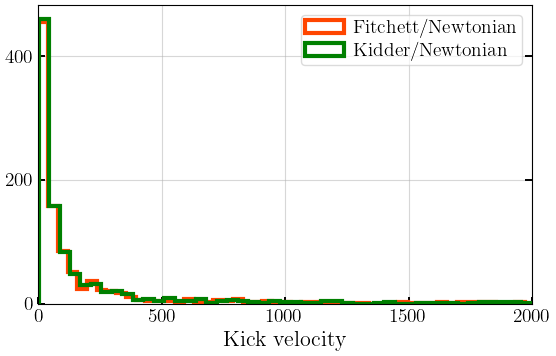

In [9]:
plt.figure(figsize=(6,4))
plt.hist(vf_fitchett, color='orangered', histtype='step', lw=3, bins=250, label='Fitchett/Newtonian');
plt.hist(vf_kidder, color='g', histtype='step', lw=3, bins=250, label='Kidder/Newtonian');
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Kick velocity', fontsize=16)
#plt.xscale('log')
plt.xlim(xmin=0,xmax=2000)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

In [30]:
a2_tilde = []
for i in range(len(m1)):
    a2_tilde.append(np.linalg.norm(s1_vec[i]))
vf_fhh_lower = [bbh_final_kick_range_from_bhpt_FHH2004(q=q_val, a_tilde_2=a_val)[1] 
               for q_val, a_val in zip(small_q, a2_tilde)]
vf_fhh_upper = [bbh_final_kick_range_from_bhpt_FHH2004(q=q_val, a_tilde_2=a_val)[0] 
               for q_val, a_val in zip(small_q, a2_tilde)]
vf_skh = [bbh_final_kick_from_bhpt_SKH2010(q=q_val, a=a_val)
               for q_val, a_val in zip(small_q, a2_tilde)]

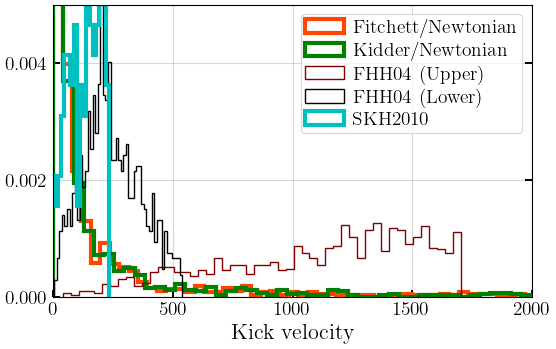

In [37]:
plt.figure(figsize=(6,4))
plt.hist(vf_fitchett, density=True, color='orangered', histtype='step', lw=3, bins=250, label='Fitchett/Newtonian');
plt.hist(vf_kidder, density=True, color='g', histtype='step', lw=3, bins=250, label='Kidder/Newtonian');
plt.hist(vf_fhh_upper, density=True, color='maroon', histtype='step', lw=1, bins=50, label='FHH04 (Upper)');
plt.hist(vf_fhh_lower, density=True, color='k', histtype='step', lw=1, bins=50, label='FHH04 (Lower)');
plt.hist(vf_skh, density=True, color='c', histtype='step', lw=3, bins=20, label='SKH2010');
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Kick velocity', fontsize=16)
#plt.xscale('log')
plt.xlim(xmin=0,xmax=2000)
plt.ylim(ymax=0.005)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()